In [30]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import matplotlib as mpl

# Подавление предупреждений
import warnings
warnings.filterwarnings("ignore")
%matplotlib inline

In [31]:
!gdown 1ERwQ5odiK1Zvi1LtjpkzCMUswYsAX8_K  # train.csv
!gdown 1fGw_-RFwvn_LEdt91Jq-7A-wzG6mmH8r  # test.csv
!gdown 199Mt4OYZNaelT83U-HGDsEYs2YcUGQ6y  # submission.csv

Downloading...
From: https://drive.google.com/uc?id=1ERwQ5odiK1Zvi1LtjpkzCMUswYsAX8_K
To: /Users/polina/VSCode/ML/DL_course/MY/train.csv
100%|████████████████████████████████████████| 664k/664k [00:00<00:00, 14.0MB/s]
Downloading...
From: https://drive.google.com/uc?id=1fGw_-RFwvn_LEdt91Jq-7A-wzG6mmH8r
To: /Users/polina/VSCode/ML/DL_course/MY/test.csv
100%|████████████████████████████████████████| 218k/218k [00:00<00:00, 6.78MB/s]
Downloading...
From: https://drive.google.com/uc?id=199Mt4OYZNaelT83U-HGDsEYs2YcUGQ6y
To: /Users/polina/VSCode/ML/DL_course/MY/submission.csv
100%|██████████████████████████████████████| 14.7k/14.7k [00:00<00:00, 37.9MB/s]


In [32]:
data = pd.read_csv('./train.csv')
data.head(10)

,ClientPeriod,MonthlySpending,TotalSpent,Sex,IsSeniorCitizen,HasPartner,HasChild,HasPhoneService,HasMultiplePhoneNumbers,HasInternetService,HasOnlineSecurityService,HasOnlineBackup,HasDeviceProtection,HasTechSupportAccess,HasOnlineTV,HasMovieSubscription,HasContractPhone,IsBillingPaperless,PaymentMethod,Churn
0,55,19.50,1026.35,Male,0,Yes,Yes,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,No,Mailed check,0
1,72,25.85,1872.2,Male,0,Yes,No,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Credit card (automatic),0
2,1,75.90,75.9,Male,0,No,No,Yes,No,Fiber optic,No,No,No,Yes,No,No,Month-to-month,Yes,Electronic check,1
3,32,79.30,2570,Female,1,Yes,No,Yes,Yes,Fiber optic,No,No,Yes,No,No,No,Month-to-month,No,Mailed check,0
4,60,115.25,6758.45,Female,0,Yes,Yes,Yes,Yes,Fiber optic,Yes,Yes,Yes,Yes,Yes,Yes,Two year,No,Credit card (automatic),0
5,25,19.80,475.2,Female,0,No,No,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Credit card (automatic),0
6,27,90.15,2423.4,Female,0,Yes,No,Yes,Yes,Fiber optic,No,No,Yes,No,No,Yes,Month-to-month,No,Bank transfer (automatic),0
7,1,45.70,45.7,Male,0,No,No,Yes,No,DSL,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,1
8,50,105.95,5341.8,Male,0,Yes,Yes,Yes,Yes,Fiber optic,Yes,No,Yes,No,Yes,Yes,Month-to-month,No,Credit card (automatic),1
9,72,61.20,4390.25,Male,0,No,No,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,Yes,Two year,Yes,Credit card (automatic),0


In [33]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5282 entries, 0 to 5281
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ClientPeriod              5282 non-null   int64  
 1   MonthlySpending           5282 non-null   float64
 2   TotalSpent                5282 non-null   object 
 3   Sex                       5282 non-null   object 
 4   IsSeniorCitizen           5282 non-null   int64  
 5   HasPartner                5282 non-null   object 
 6   HasChild                  5282 non-null   object 
 7   HasPhoneService           5282 non-null   object 
 8   HasMultiplePhoneNumbers   5282 non-null   object 
 9   HasInternetService        5282 non-null   object 
 10  HasOnlineSecurityService  5282 non-null   object 
 11  HasOnlineBackup           5282 non-null   object 
 12  HasDeviceProtection       5282 non-null   object 
 13  HasTechSupportAccess      5282 non-null   object 
 14  HasOnlin

In [34]:
data.isna().sum()

ClientPeriod                0
MonthlySpending             0
TotalSpent                  0
Sex                         0
IsSeniorCitizen             0
HasPartner                  0
HasChild                    0
HasPhoneService             0
HasMultiplePhoneNumbers     0
HasInternetService          0
HasOnlineSecurityService    0
HasOnlineBackup             0
HasDeviceProtection         0
HasTechSupportAccess        0
HasOnlineTV                 0
HasMovieSubscription        0
HasContractPhone            0
IsBillingPaperless          0
PaymentMethod               0
Churn                       0
dtype: int64

In [35]:
# Числовые признаки
num_cols = [
    'ClientPeriod',
    'MonthlySpending',
    'TotalSpent'
]

# Категориальные признаки
cat_cols = [
    'Sex',
    'IsSeniorCitizen',
    'HasPartner',
    'HasChild',
    'HasPhoneService',
    'HasMultiplePhoneNumbers',
    'HasInternetService',
    'HasOnlineSecurityService',
    'HasOnlineBackup',
    'HasDeviceProtection',
    'HasTechSupportAccess',
    'HasOnlineTV',
    'HasMovieSubscription',
    'HasContractPhone',
    'IsBillingPaperless',
    'PaymentMethod'
]

feature_cols = num_cols + cat_cols
target_col = 'Churn'

## Анализ данных

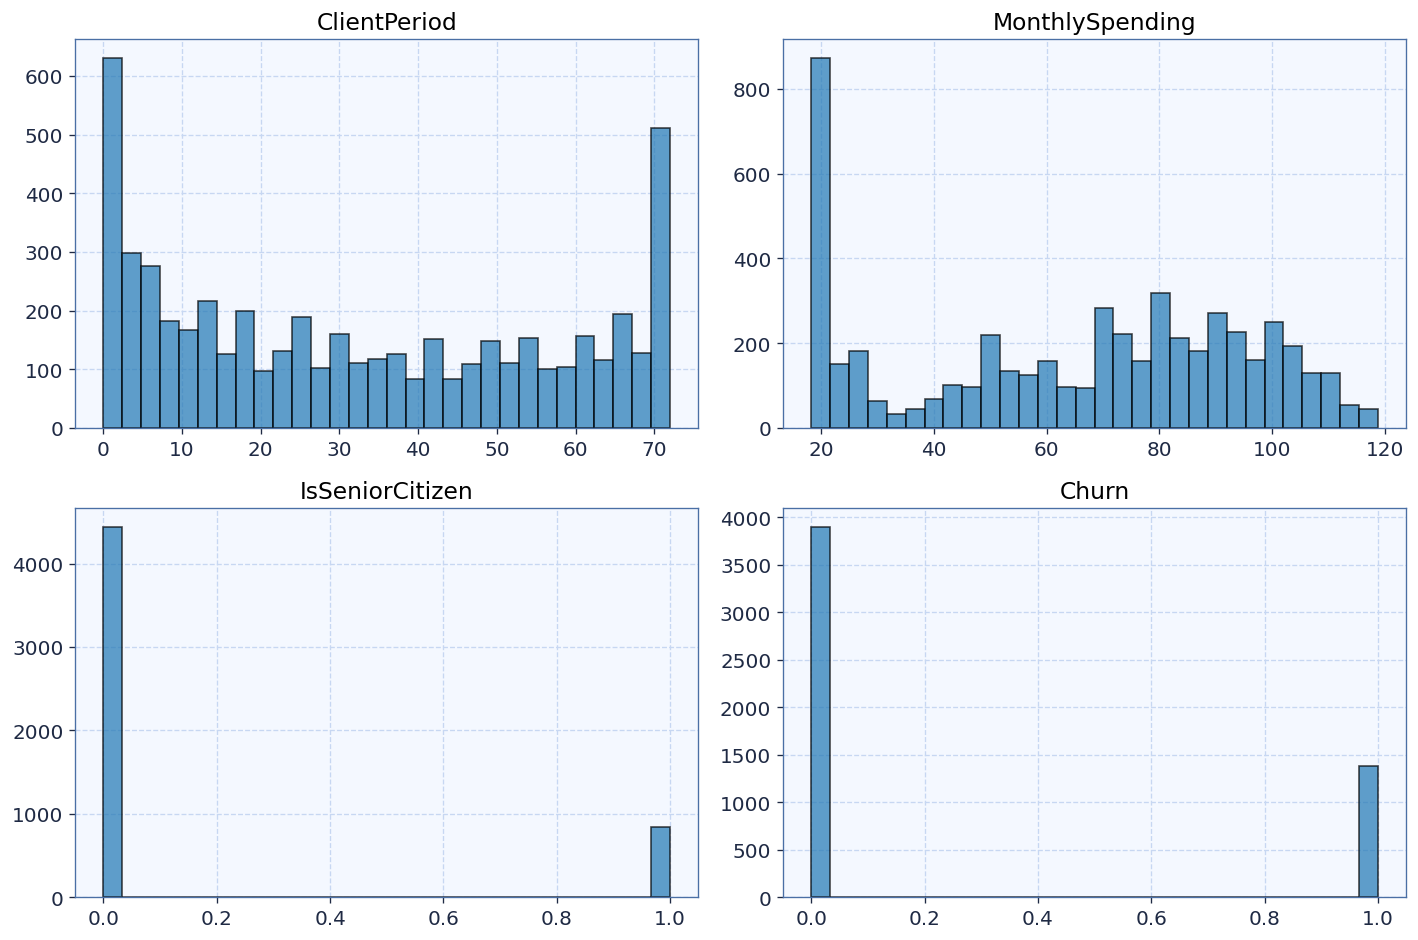

In [36]:
data.hist(figsize=(12, 8), bins=30, edgecolor='black', alpha=0.7)
plt.tight_layout()
plt.show()

In [37]:
data['TotalSpent'] = data['TotalSpent'].replace(" ", 0).astype('float')

display(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5282 entries, 0 to 5281
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ClientPeriod              5282 non-null   int64  
 1   MonthlySpending           5282 non-null   float64
 2   TotalSpent                5282 non-null   float64
 3   Sex                       5282 non-null   object 
 4   IsSeniorCitizen           5282 non-null   int64  
 5   HasPartner                5282 non-null   object 
 6   HasChild                  5282 non-null   object 
 7   HasPhoneService           5282 non-null   object 
 8   HasMultiplePhoneNumbers   5282 non-null   object 
 9   HasInternetService        5282 non-null   object 
 10  HasOnlineSecurityService  5282 non-null   object 
 11  HasOnlineBackup           5282 non-null   object 
 12  HasDeviceProtection       5282 non-null   object 
 13  HasTechSupportAccess      5282 non-null   object 
 14  HasOnlin

None

In [38]:
invalid_values = data[pd.to_numeric(
    data['TotalSpent'], errors='coerce').isna()]
print('Количество некорректных значений TotalSpent:', len(invalid_values))
display(invalid_values[['TotalSpent']])

Количество некорректных значений TotalSpent: 0


,TotalSpent


In [39]:
data.duplicated(keep=False).sum()

28

In [40]:
data.drop_duplicates(inplace=True)

duplicates_count = data.drop(target_col, axis=1).duplicated(keep=False).sum()

print(f"Количество дубликатов : {duplicates_count}")

Количество дубликатов : 16


In [41]:
data = data.drop_duplicates(subset=data.columns
                            .difference(['Churn']), keep='first')

duplicates_count = data.drop('Churn', axis=1).duplicated(keep=False).sum()

print(f"Количество дубликатов : {duplicates_count}")

Количество дубликатов : 0


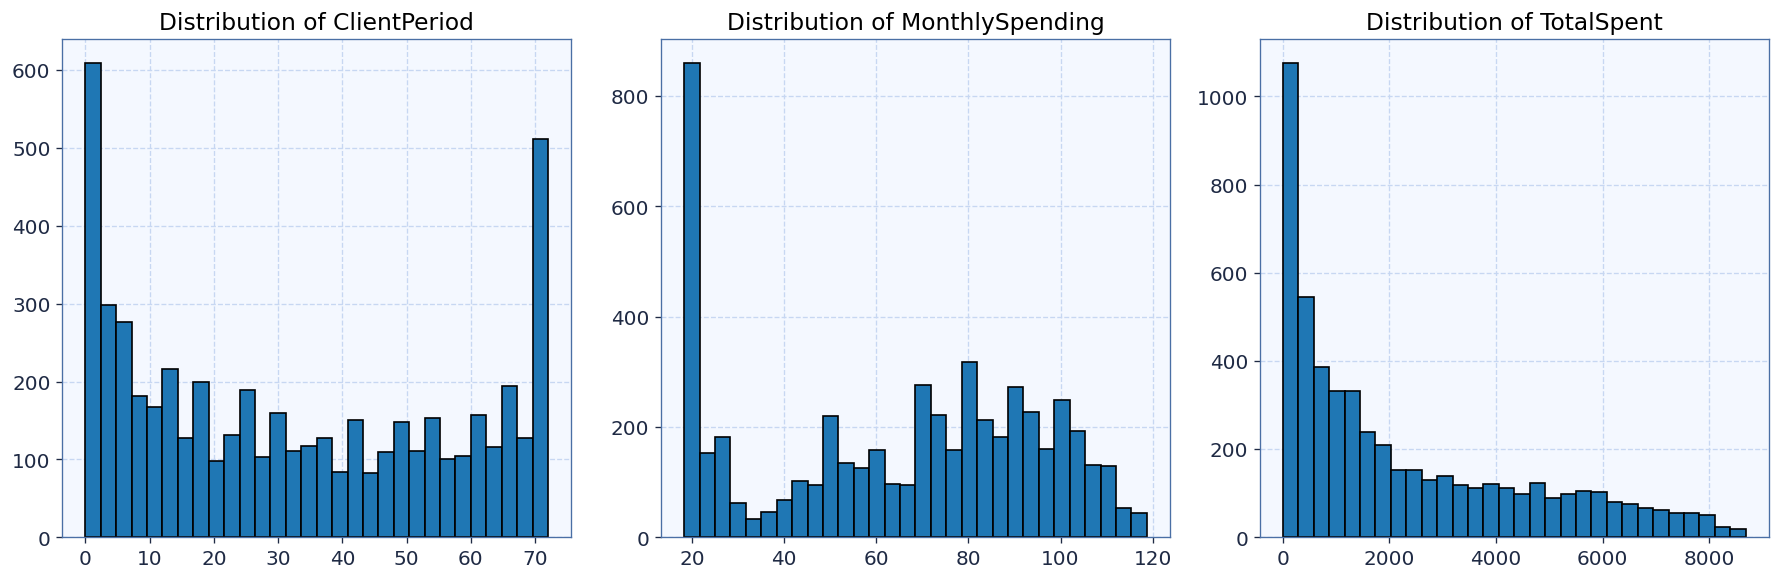

In [42]:
plt.figure(figsize=(15, 5))
for i, col in enumerate(num_cols, 1):
    plt.subplot(1, 3, i)
    plt.hist(data[col], bins=30, edgecolor='black')
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

In [43]:
for i in cat_cols:
    print(data[i].value_counts())
    print('\n')

Sex
Male      2644
Female    2616
Name: count, dtype: int64


IsSeniorCitizen
0    4419
1     841
Name: count, dtype: int64


HasPartner
No     2683
Yes    2577
Name: count, dtype: int64


HasChild
No     3654
Yes    1606
Name: count, dtype: int64


HasPhoneService
Yes    4739
No      521
Name: count, dtype: int64


HasMultiplePhoneNumbers
No                  2489
Yes                 2250
No phone service     521
Name: count, dtype: int64


HasInternetService
Fiber optic    2335
DSL            1797
No             1128
Name: count, dtype: int64


HasOnlineSecurityService
No                     2603
Yes                    1529
No internet service    1128
Name: count, dtype: int64


HasOnlineBackup
No                     2323
Yes                    1809
No internet service    1128
Name: count, dtype: int64


HasDeviceProtection
No                     2308
Yes                    1824
No internet service    1128
Name: count, dtype: int64


HasTechSupportAccess
No                     2595
Ye

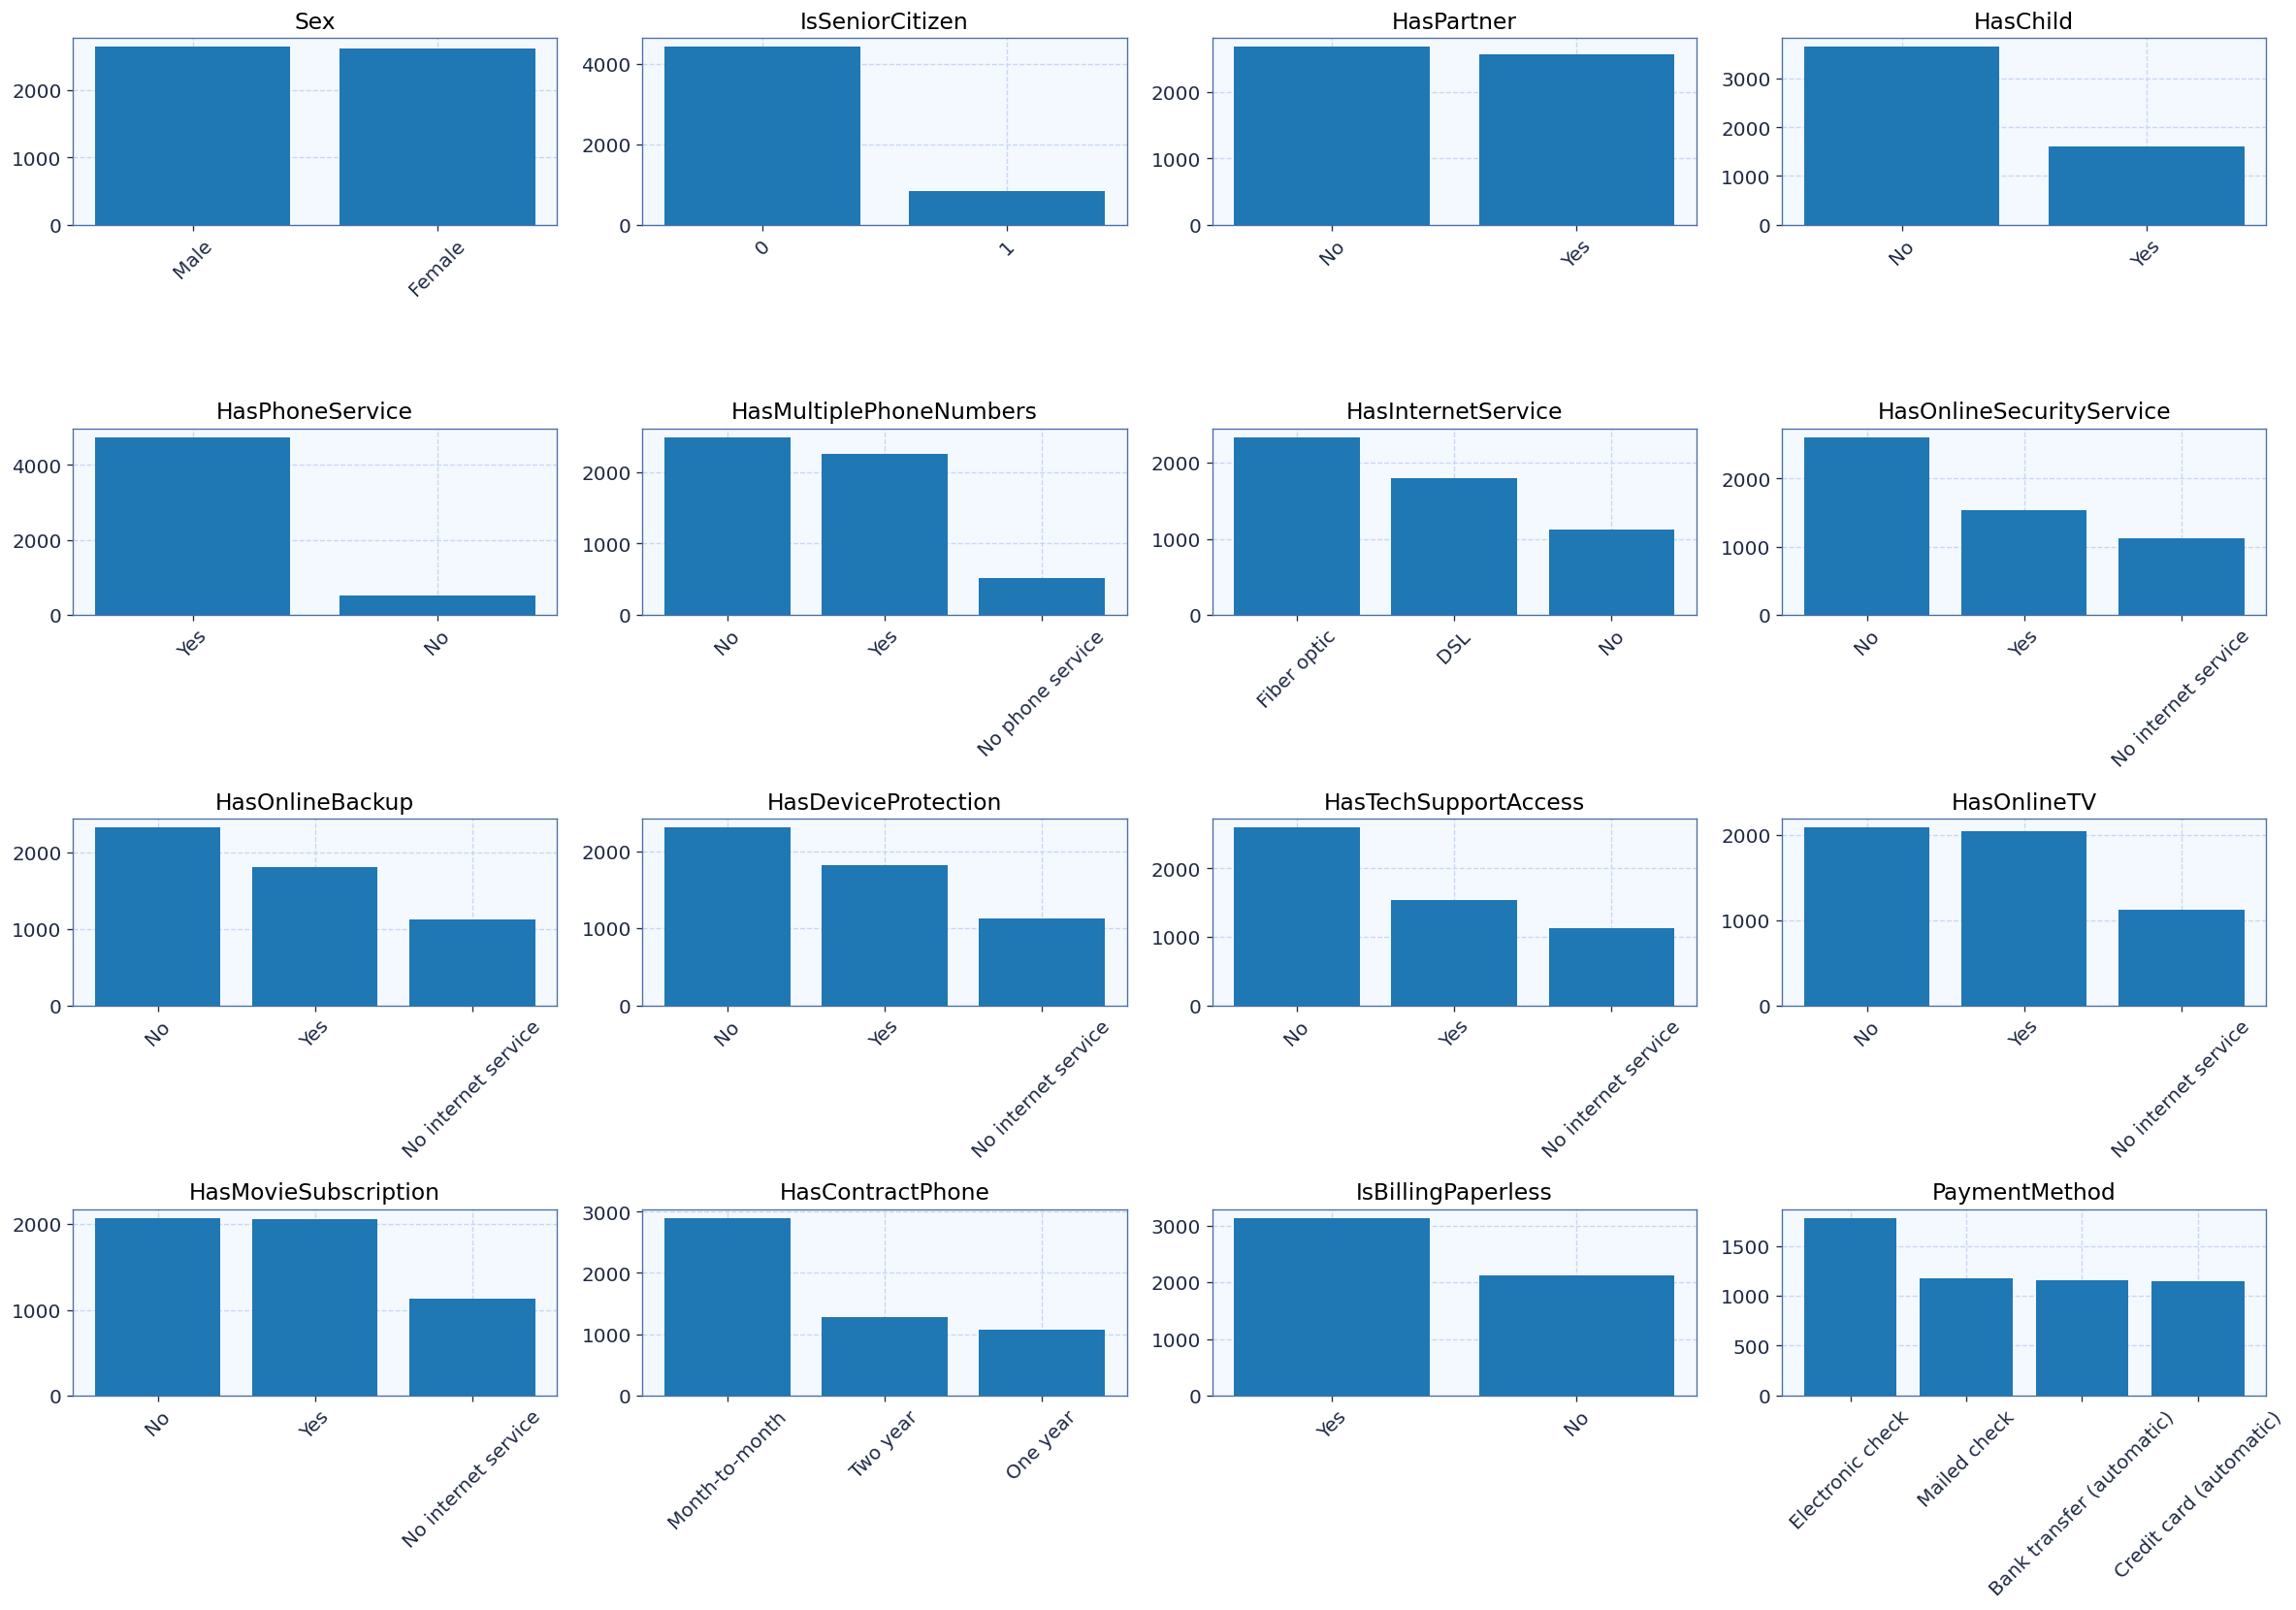

In [44]:
n_cols = 4
n_rows = (len(cat_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 14))
axes = axes.flatten()

for ax, col in zip(axes, cat_cols):
    counts = data[col].value_counts()
    ax.bar(counts.index.astype(str), counts.values)
    ax.set_title(col)
    ax.tick_params(axis='x', rotation=45)

for i in range(len(cat_cols), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

In [45]:
y = data[target_col]
y.shape

(5260,)

Распределение классов Churn:
Churn
0    3891
1    1369
Name: count, dtype: int64

Доли классов:
Churn
0    0.74
1    0.26
Name: proportion, dtype: float64


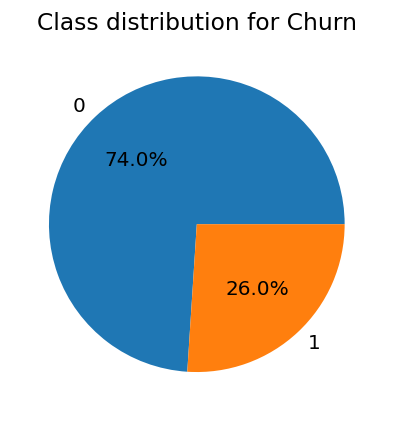

In [46]:
churn_counts = data[target_col].value_counts()
print('Распределение классов {}:\n{}'.format(target_col, churn_counts))

class_distribution = pd.Series(y).value_counts(
    normalize=True).sort_index()
print("\nДоли классов:")
print(class_distribution.round(3))

plt.figure(figsize=(4, 4))
plt.pie(churn_counts, labels=churn_counts.index, autopct='%1.1f%%')
plt.title(f'Class distribution for {target_col}')
plt.show()

Классы несбалансированны

В таких случаях нужно:
1) не использовать accuracy как метрику 
2) использовать методы борьбы с imbalanced dataset (обычно если датасет сильно несбалансирован, т.е. класса 1 в 20 раз меньше класса 0).

In [47]:
X = data[num_cols + cat_cols]
X.shape

(5260, 19)

### Применение линейных моделей

In [48]:
from sklearn.pipeline import make_pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, RobustScaler, LabelEncoder, OneHotEncoder
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.model_selection import train_test_split, GridSearchCV
import catboost
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.impute import SimpleImputer

In [49]:
scaler = StandardScaler()
encoder = OneHotEncoder(handle_unknown='ignore')
imputer = SimpleImputer(strategy='mean')

num_transformer = make_pipeline(imputer, scaler)
cat_transformer = make_pipeline(encoder)


preprocessor = ColumnTransformer(
    transformers=[('num', num_transformer, num_cols),
                  ('cat', cat_transformer, cat_cols)]
    )

In [50]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=42)

Рассмотрим логистическую регрессию

In [51]:
model_log_reg = LogisticRegressionCV(scoring='roc_auc',
                                     refit=True,
                                     Cs=np.logspace(-5,5,11),
                                     cv=7,
                                     random_state=42)


pipe_log_reg = make_pipeline(preprocessor, model_log_reg)
pipe_log_reg.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('columntransformer', ...), ('logisticregressioncv', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the diffe

In [52]:
opt_C = pipe_log_reg.named_steps['logisticregressioncv'].C_[0]
print("Оптимальное C:", opt_C)

roc_auc_log_reg = pipe_log_reg.score(X_train, y_train)
print(f'ROC-AUC на обучающем наборе: {roc_auc_log_reg}')

Оптимальное C: 100.0
ROC-AUC на обучающем наборе: 0.8481426371536072


In [53]:
y_train_predicted_log_reg = pipe_log_reg.predict_proba(X_train)[:, 1]
y_valid_predicted_log_reg = pipe_log_reg.predict_proba(X_valid)[:, 1]

print("Train ROC-AUC:", roc_auc_score(y_train, y_train_predicted_log_reg))
print("Valid ROC-AUC:", roc_auc_score(y_valid, y_valid_predicted_log_reg))

Train ROC-AUC: 0.8481426371536072
Valid ROC-AUC: 0.8506576691077085


In [54]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC

model_svm = SVC(probability=True,
                random_state=42)

pipe_svm = make_pipeline(preprocessor, model_svm)

param_grid = {
    'svc__C': [0.1, 1, 10],
    'svc__kernel': ['rbf', 'linear'],
    'svc__gamma': ['scale', 0.01]
}

grid_search = GridSearchCV(pipe_svm, param_grid, cv=5,
                           scoring='roc_auc', n_jobs=-1)

grid_search.fit(X_train, y_train)

print("Лучшие параметры:", grid_search.best_params_)
print("Лучший AUC на обучающем наборе:", grid_search.best_score_)

y_valid_predicted_svm = grid_search.best_estimator_.predict_proba(X_valid)[
    :, 1]
print("Valid ROC-AUC:", roc_auc_score(y_valid, y_valid_predicted_svm))

/Users/polina/miniforge3/envs/ml_course/lib/python3.11/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/Users/polina/miniforge3/envs/ml_course/lib/python3.11/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/Users/polina/miniforge3/envs/ml_course/lib/python3.11/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. R

Лучшие параметры: {'svc__C': 0.1, 'svc__gamma': 0.01, 'svc__kernel': 'rbf'}
Лучший AUC на обучающем наборе: 0.8362032170512723
Valid ROC-AUC: 0.8387903730153927


### Применение градиентного бустинга

In [55]:
import optuna
from catboost import CatBoostClassifier, Pool


def objective(trial):
    params = {
        'iterations': 1500,
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.1, log=True),
        'depth': trial.suggest_int('depth', 4, 10),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1, 10),
        'random_strength': trial.suggest_float('random_strength', 1e-9, 10, log=True),
        'bagging_temperature': trial.suggest_float('bagging_temperature', 0, 1),
        'border_count': trial.suggest_int('border_count', 32, 255),
        
        'auto_class_weights': 'Balanced',
        
        'loss_function': 'Logloss',
        'eval_metric': 'AUC',
        'verbose': False,
        'task_type': 'CPU',
        'cat_features': cat_cols
    }

    model = CatBoostClassifier(**params)
    
    model.fit(X_train, y_train, 
              eval_set=(X_valid, y_valid), 
              early_stopping_rounds=100,
              verbose=False)
    
    return model.best_score_['validation']['AUC']

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=30)

[I 2026-03-22 16:57:53,005] A new study created in memory with name: no-name-1f25c9fb-2a12-462a-a1fa-4af20d5bb662
[I 2026-03-22 16:57:58,533] Trial 0 finished with value: 0.8511998426435877 and parameters: {'learning_rate': 0.006542532459747708, 'depth': 8, 'l2_leaf_reg': 1.6507549798165067, 'random_strength': 0.08654753309592854, 'bagging_temperature': 0.720458464740865, 'border_count': 126}. Best is trial 0 with value: 0.8511998426435877.
[I 2026-03-22 16:57:59,463] Trial 1 finished with value: 0.8510434949262644 and parameters: {'learning_rate': 0.05905455112044367, 'depth': 5, 'l2_leaf_reg': 6.357584011862471, 'random_strength': 0.0006626774029321081, 'bagging_temperature': 0.789911375647821, 'border_count': 112}. Best is trial 0 with value: 0.8511998426435877.
[I 2026-03-22 16:58:00,460] Trial 2 finished with value: 0.8508972341584458 and parameters: {'learning_rate': 0.02950678823964539, 'depth': 4, 'l2_leaf_reg': 5.998257968403336, 'random_strength': 0.025762167477399758, 'baggi

In [56]:
final_model_catboost = CatBoostClassifier(
    **study.best_params,
    cat_features=cat_cols,
    auto_class_weights='Balanced',
    verbose=100, 
    iterations=1500
)

final_model_catboost.fit(X=X, y=y)

y_valid_predicted_catboost = final_model_catboost.predict_proba(X=X)[:, 1]
roc_auc_catboost = roc_auc_score(y, y_valid_predicted_catboost)

print(f'ROC-AUC validation CatBoost: {roc_auc_catboost:.6f}')

0:	learn: 0.6843022	total: 6.62ms	remaining: 9.93s
100:	learn: 0.4873509	total: 406ms	remaining: 5.63s
200:	learn: 0.4730997	total: 849ms	remaining: 5.48s
300:	learn: 0.4668463	total: 1.24s	remaining: 4.95s
400:	learn: 0.4604766	total: 1.65s	remaining: 4.52s
500:	learn: 0.4546652	total: 2.07s	remaining: 4.13s
600:	learn: 0.4501258	total: 2.5s	remaining: 3.74s
700:	learn: 0.4456091	total: 2.94s	remaining: 3.35s
800:	learn: 0.4415227	total: 3.38s	remaining: 2.95s
900:	learn: 0.4378801	total: 3.81s	remaining: 2.53s
1000:	learn: 0.4344116	total: 4.28s	remaining: 2.13s
1100:	learn: 0.4308170	total: 4.76s	remaining: 1.73s
1200:	learn: 0.4267708	total: 5.26s	remaining: 1.31s
1300:	learn: 0.4234477	total: 5.71s	remaining: 873ms
1400:	learn: 0.4201395	total: 6.15s	remaining: 435ms
1499:	learn: 0.4169999	total: 6.61s	remaining: 0us
ROC-AUC validation CatBoost: 0.878179


### Предсказания

In [57]:
X_test = pd.read_csv('./test.csv')
submission = pd.read_csv('./submission.csv')

submission['Churn'] = final_model_catboost.predict_proba(X_test)[:, 1]


submission.set_index('Id', inplace=True)
submission.to_csv('./my_submission.csv', index=True)